0

In [1]:
!pip -q install ipyleaflet ipywidgets openpyxl osmnx networkx geopandas shapely pyproj rtree



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Блок 1: Ввод анализируемого объекта

1

In [3]:
from google.colab import output
output.enable_custom_widget_manager()

2

In [2]:
import os

import ipywidgets as widgets
from IPython.display import display
from ipyleaflet import Map, Marker, basemaps, basemap_to_tiles

import osmnx as ox
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point

from openpyxl import load_workbook

3

In [3]:
city = input("Введите название города (метаданные): ").strip()
region = input("Введите регион (метаданные): ").strip()

print("Город:", city)
print("Регион:", region)


Город: Ff
Регион: Fff


4

In [ ]:
center = (61.0, 105.0)

coord_box = widgets.Text(
    value="",
    placeholder="Кликните по карте…",
    description="Точка:",
    disabled=True,
    layout=widgets.Layout(width="420px")
)

m = Map(
    center=center,
    zoom=3,
    basemap=basemap_to_tiles(basemaps.OpenStreetMap.Mapnik),
    scroll_wheel_zoom=True
)

selected = {"lat": None, "lon": None, "marker": None}

def handle_click(**kwargs):
    if kwargs.get("type") == "click":
        lat, lon = kwargs.get("coordinates")
        selected["lat"], selected["lon"] = float(lat), float(lon)
        coord_box.value = f"{selected['lat']:.6f}, {selected['lon']:.6f}"

        if selected["marker"] is not None:
            m.remove_layer(selected["marker"])
        selected["marker"] = Marker(location=(selected["lat"], selected["lon"]))
        m.add_layer(selected["marker"])

m.on_interaction(handle_click)
display(coord_box, m)


Text(value='', description='Точка:', disabled=True, layout=Layout(width='420px'), placeholder='Кликните по кар…

Map(center=[61.0, 105.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

5

In [7]:
proj_lat, proj_lon = selected["lat"], selected["lon"]
if proj_lat is None or proj_lon is None:
    raise ValueError("Точка проекта не выбрана. Кликните по карте и выполните ячейку снова")

coordinate_str = f"{proj_lat:.6f}, {proj_lon:.6f}"
print("Точка проекта:", coordinate_str)


Точка проекта: 58.373458, 45.516443


6 - Категоризация объекта

In [9]:
R_CAT = 1500

pt = Point(proj_lon, proj_lat)

def only_polygons(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf is None or gdf.empty or "geometry" not in gdf.columns:
        return gdf
    g = gdf[~gdf.geometry.isna()].copy()
    if g.empty:
        return g
    return g[g.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]

def point_in_polygons(gdf: gpd.GeoDataFrame, point: Point) -> bool:
    g = only_polygons(gdf)
    if g is None or g.empty:
        return False
    return bool(g.geometry.apply(lambda geom: geom.covers(point)).any())

tags_park = {"leisure": "park"}
tags_wood = {"natural": "wood"}

gdf_park = ox.features_from_point((proj_lat, proj_lon), tags_park, dist=R_CAT)
gdf_wood = ox.features_from_point((proj_lat, proj_lon), tags_wood, dist=R_CAT)

# CRS
for name in ["gdf_park", "gdf_wood"]:
    gdf = locals()[name]
    if gdf is None or gdf.empty:
        continue
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    else:
        locals()[name] = gdf.to_crs(epsg=4326)

in_park_poly = point_in_polygons(gdf_park, pt)
in_wood_poly = point_in_polygons(gdf_wood, pt)

print("OSM-проверка (только полигоны):")
print(" - входит в leisure=park:", in_park_poly)
print(" - входит в natural=wood:", in_wood_poly)

if not (in_park_poly or in_wood_poly):
    raise ValueError(
        "Типология 'park' НЕ подтверждена: точка не входит ни в один полигон "
        "leisure=park или natural=wood (по данным OSM). Выберите другую точку."
    )

category = "park"
print("Типология подтверждена:", category)


OSM-проверка (только полигоны):
 - входит в leisure=park: False
 - входит в natural=wood: False


ValueError: Типология 'park' НЕ подтверждена: точка не входит ни в один полигон leisure=park или natural=wood (по данным OSM). Выберите другую точку.

7

In [9]:
TEMPLATE_PATH = "/content/drive/MyDrive/НИР/04-Template_new_object.xlsx"
OUT_PATH = "/content/evaluation/05-New_object_filled.xlsx"
INPUT_ROW = 4  # строка нового объекта

if not os.path.exists(TEMPLATE_PATH):
    raise FileNotFoundError(f"Шаблон не найден: {TEMPLATE_PATH}")

def find_header_columns(ws, required_headers, search_rows=15):
    required_lower = {h.lower(): h for h in required_headers}

    for r in range(1, search_rows + 1):
        mapping = {}
        for c in range(1, ws.max_column + 1):
            v = ws.cell(row=r, column=c).value
            if isinstance(v, str):
                key = v.strip().lower()
                if key in required_lower:
                    mapping[required_lower[key]] = c

        if all(h in mapping for h in required_headers):
            return r, mapping

    raise ValueError(f"Не найдена строка заголовков с полями {required_headers} в первых {search_rows} строках.")

required = ["№", "Город", "Регион", "name", "coordinate", "category"]

wb = load_workbook(TEMPLATE_PATH)
ws = wb.active  # при необходимости: wb["ИмяЛиста"]

header_row, col = find_header_columns(ws, required_headers=required, search_rows=15)

ws.cell(row=INPUT_ROW, column=col["№"]).value = 0
ws.cell(row=INPUT_ROW, column=col["Город"]).value = city
ws.cell(row=INPUT_ROW, column=col["Регион"]).value = region
ws.cell(row=INPUT_ROW, column=col["name"]).value = "object"
ws.cell(row=INPUT_ROW, column=col["coordinate"]).value = coordinate_str
ws.cell(row=INPUT_ROW, column=col["category"]).value = category

wb.save(OUT_PATH)
print("Готово:", OUT_PATH)


Готово: /content/evaluation/05-New_object_filled.xlsx


### Блок 1.1: Построение изохрона доступности на основе времени

8 - Построение изохрона доступности

In [10]:
TIME_BINS = [300, 600, 900, 1200, 1500]
WALK_SPEED_MPS = 1.4

GRAPH_DIST_M = int(TIME_BINS[-1] * WALK_SPEED_MPS * 1.3)
GRAPH_DIST_M


2730

9

In [11]:
G = ox.graph_from_point(
    (proj_lat, proj_lon),
    dist=GRAPH_DIST_M,
    network_type="walk",
    simplify=True
)

for u, v, k, data in G.edges(keys=True, data=True):
    length_m = data.get("length")
    if length_m is None:
        data["travel_time"] = None
    else:
        data["travel_time"] = float(length_m) / WALK_SPEED_MPS


10

In [12]:
orig = ox.distance.nearest_nodes(G, X=proj_lon, Y=proj_lat)
travel_times = nx.single_source_dijkstra_path_length(G, orig, weight="travel_time")
nx.set_node_attributes(G, travel_times, "travel_time")

len(travel_times), "узлов с рассчитанным временем"


(2855, 'узлов с рассчитанным временем')

11

In [13]:
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G, nodes=True, edges=True)

nodes_m = nodes_gdf.to_crs(nodes_gdf.estimate_utm_crs())

iso_polys = []
prev = 0

for t in TIME_BINS:
    sub = nodes_m[nodes_m["travel_time"] <= t]
    geom = None if sub.empty else sub.geometry.unary_union.convex_hull.buffer(150)

    iso_polys.append({"t_from": prev, "t_to": t, "geometry": geom})
    prev = t

iso_gdf = gpd.GeoDataFrame(iso_polys, crs=nodes_m.crs)

# кольца: разность соседних полигонов
rings = iso_gdf.copy()
ring_geoms = []
for i in range(len(iso_gdf)):
    geom = iso_gdf.loc[i, "geometry"]
    if geom is None:
        ring = None
    elif i == 0:
        ring = geom
    else:
        prev_geom = iso_gdf.loc[i-1, "geometry"]
        ring = geom.difference(prev_geom) if prev_geom is not None else geom
    ring_geoms.append(ring)

rings["geometry"] = ring_geoms

rings_wgs = rings.to_crs(epsg=4326)

out_geojson = "06-isochrones_5x300s.geojson"
rings_wgs.to_file(out_geojson, driver="GeoJSON")

out_geojson


/tmp/ipython-input-2506599126.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = None if sub.empty else sub.geometry.unary_union.convex_hull.buffer(150)
/tmp/ipython-input-2506599126.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = None if sub.empty else sub.geometry.unary_union.convex_hull.buffer(150)
/tmp/ipython-input-2506599126.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = None if sub.empty else sub.geometry.unary_union.convex_hull.buffer(150)
/tmp/ipython-input-2506599126.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = None if sub.empty else sub.geometry.unary_union.convex_hull.buffer(150)
/tmp/ipython-input-2506599126.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' me

'06-isochrones_5x300s.geojson'

12

In [14]:
import folium

m_iso = folium.Map(location=[proj_lat, proj_lon], zoom_start=14, control_scale=True)
folium.Marker([proj_lat, proj_lon], tooltip="Точка проекта").add_to(m_iso)

folium.GeoJson(
    rings_wgs,
    tooltip=folium.GeoJsonTooltip(fields=["t_from", "t_to"], aliases=["От (с)", "До (с)"])
).add_to(m_iso)

m_iso


## Блок 2: Анализ близлежащих точек интереса по категориям

13

In [15]:
import pandas as pd

TAGS_PATH = "/content/drive/MyDrive/НИР/05-Category_of_analysis.xlsx"
tags_df = pd.read_excel(TAGS_PATH)

tags_df.columns = [c.strip() for c in tags_df.columns]

required_cols = {"Metric", "Key", "Value"}
if not required_cols.issubset(set(tags_df.columns)):
    raise ValueError(f"В файле тегов должны быть колонки {required_cols}, сейчас: {list(tags_df.columns)}")

ZONE_LABELS = {
    (0, 300): "5<",
    (300, 600): "5<10",
    (600, 900): "10<15",
    (900, 1200): "15<20",
    (1200, 1500): "20<25",
}

SPECIAL_TOTAL_ONLY = {"Religion", "Sport_big", "Sport_small"}


14

In [16]:
import geopandas as gpd

rings_m = rings_wgs.to_crs(rings_wgs.estimate_utm_crs())

def zone_label(row):
    key = (int(row["t_from"]), int(row["t_to"]))
    return ZONE_LABELS.get(key)

rings_m["zone"] = rings_m.apply(zone_label, axis=1)
rings_m = rings_m.dropna(subset=["zone"]).copy()

outer_poly_wgs = rings_wgs.unary_union


/tmp/ipython-input-955618238.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outer_poly_wgs = rings_wgs.unary_union


15

In [17]:
from openpyxl import load_workbook

OUT_PATH = "/content/evaluation/05-New_object_filled.xlsx"
SHEET_NAME = "Лист1"
ROW_HDR = 1
ROW_PHASE = 2
ROW_ZONE = 3
ROW_DATA = 4

wb = load_workbook(OUT_PATH)
ws = wb[SHEET_NAME]

def norm(s):
    return str(s).strip().lower() if s is not None else ""

col_map = {}
col_total = {}

max_col = ws.max_column

for c in range(1, max_col + 1):
    h = ws.cell(row=ROW_HDR, column=c).value
    phase = ws.cell(row=ROW_PHASE, column=c).value
    z = ws.cell(row=ROW_ZONE, column=c).value

    h_norm = str(h).strip() if h is not None else None
    if not h_norm:
        continue

    if norm(phase) != "after":
        continue

    z_norm = str(z).strip() if z is not None else ""

    if z_norm in set(ZONE_LABELS.values()):
        col_map[(h_norm, z_norm)] = c
    else:
        col_total[h_norm] = c

metrics = sorted(tags_df["Metric"].dropna().astype(str).unique())
missing = []
for m in metrics:
    if m in SPECIAL_TOTAL_ONLY:
        if m not in col_total and not any((m, zl) in col_map for zl in ZONE_LABELS.values()):
            missing.append(m)
    else:
        for zl in ZONE_LABELS.values():
            if (m, zl) not in col_map:
                missing.append(f"{m}/{zl}")

if missing:
    raise ValueError("Не найдены нужные столбцы в шаблоне (проверь строки 1–3):\n" + "\n".join(map(str, missing)))


16

In [18]:
import osmnx as ox
from shapely.geometry import Point

def build_tags_for_metric(df_metric: pd.DataFrame) -> dict:
    """
    OSMnx принимает tags как dict: key -> value или key -> [values]
    """
    tags = {}
    for k, sub in df_metric.groupby("Key"):
        vals = sub["Value"].dropna().astype(str).unique().tolist()
        if len(vals) == 1:
            tags[str(k)] = vals[0]
        else:
            tags[str(k)] = vals
    return tags

def points_only(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf is None or gdf.empty:
        return gdf
    g = gdf[~gdf.geometry.isna()].copy()
    if g.empty:
        return g
    return g[g.geometry.geom_type == "Point"]

results = {}
totals = {}

for metric in metrics:
    df_m = tags_df[tags_df["Metric"].astype(str) == metric]
    tags = build_tags_for_metric(df_m)

    gdf = ox.features_from_polygon(outer_poly_wgs, tags)
    gdf = points_only(gdf)

    if gdf is None or gdf.empty:
        if metric in SPECIAL_TOTAL_ONLY:
            totals[metric] = 0
        else:
            for zl in ZONE_LABELS.values():
                results[(metric, zl)] = 0
        continue

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    gdf_m = gdf.to_crs(rings_m.crs)

    zone_counts = {}
    for _, ring in rings_m.iterrows():
        zl = ring["zone"]
        poly = ring["geometry"]
        cnt = int(gdf_m.geometry.within(poly).sum())
        zone_counts[zl] = cnt

    if metric in SPECIAL_TOTAL_ONLY:
        totals[metric] = sum(zone_counts.values())
    else:
        for zl in ZONE_LABELS.values():
            results[(metric, zl)] = zone_counts.get(zl, 0)


17

In [20]:
# обычные метрики: по 5 зонам
for (metric, zl), val in results.items():
    c = col_map[(metric, zl)]
    ws.cell(row=ROW_DATA, column=c).value = int(val)

for metric, val in totals.items():
    if metric in col_total:
        c = col_total[metric]
    else:
        c = col_map[(metric, "5<")]
    ws.cell(row=ROW_DATA, column=c).value = int(val)

wb.save(OUT_PATH)
print("Готово, скачайте и обновите файл:", OUT_PATH)


Готово, скачайте и обновите файл: /content/evaluation/05-New_object_filled.xlsx


## Блок 4: Оценка и рекомендации
Необходимо скачать, открыть, разрешить редактирование файла `05-New_object_filled` для корректной работы формул Excel, затем сохранить и загрузить обновленный файл в `/content/evaluation`

In [21]:
import numpy as np
import pandas as pd
from openpyxl import load_workbook
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/НИР/03-Только парки.xlsx"
NEW_PATH  = "/content/evaluation/05-New_object_filled.xlsx"

SHEET_BASE = "Лист1"
SHEET_NEW  = "Лист1"

ROW_HDR = 1
ROW_PHASE = 2
ROW_ZONE = 3
ROW_DATA_START = 4

K = 20  # число ближайших аналогов
W_IMPORTANT = 2.0
EPS = 1e-9

IMPORTANT_METRICS_PARK = {"POI", "Culture", "Game", "sport_local"}  # потенциальное расширение метрик в дальнейшем, когда внесу категории Embankment, Square


In [22]:
def norm_str(x):
    return str(x).strip().lower() if x is not None else ""

def phase_norm(x):
    s = norm_str(x)
    if "before" in s or "до" in s:
        return "before"
    if "after" in s or "после" in s:
        return "after"
    return None

def read_sum_columns(ws):
    """
    Ищет Sum-колонки по схеме:
    - строка 1: метрика (POI/Culture/...) повторяется над блоком, а у итогов стоит 'Sum'
    - строка 2: Before/After или До/После
    - Sum наследует метрику слева (последняя встреченная метрика ≠ 'Sum')
    """
    sum_cols = {}
    current_metric = None

    for c in range(1, ws.max_column + 1):
        h1 = ws.cell(row=ROW_HDR, column=c).value   # POI / Sum / Culture ...
        h2 = ws.cell(row=ROW_PHASE, column=c).value # Before/After или До/После

        h1s = str(h1).strip() if h1 is not None else ""
        ph = phase_norm(h2)

        # обновляем текущую метрику (если это не Sum)
        if h1s and h1s.lower() != "sum":
            current_metric = h1s

        # фиксируем Sum-колонки
        if h1s.lower() == "sum" and current_metric and ph in {"before", "after"}:
            sum_cols[(current_metric, ph)] = c

    return sum_cols


In [23]:
wb_base = load_workbook(BASE_PATH, data_only=True)
ws_base = wb_base[wb_base.sheetnames[0]]

base_sum_cols = read_sum_columns(ws_base)

metrics_base = sorted({m for (m, ph) in base_sum_cols.keys()})
metrics_ok = []
for m in metrics_base:
    if (m, "before") in base_sum_cols and (m, "after") in base_sum_cols:
        metrics_ok.append(m)

if not metrics_ok:
    raise ValueError("Не найдено Sum Before/After в базе")

base_rows = []
max_row = ws_base.max_row
for r in range(ROW_DATA_START, max_row + 1):
    num = ws_base.cell(row=r, column=1).value
    if num is None:
        continue
    row = {"row": r, "№": num}
    row["city"] = ws_base.cell(row=r, column=2).value
    row["region"] = ws_base.cell(row=r, column=3).value
    row["name"] = ws_base.cell(row=r, column=4).value
    base_rows.append(row)

base_df = pd.DataFrame(base_rows)

# добавляются метрики
for m in metrics_ok:
    c_b = base_sum_cols[(m, "before")]
    c_a = base_sum_cols[(m, "after")]
    base_df[f"{m}__before"] = [ws_base.cell(row=r, column=c_b).value for r in base_df["row"]]
    base_df[f"{m}__after"]  = [ws_base.cell(row=r, column=c_a).value for r in base_df["row"]]
    base_df[f"{m}__delta"]  = base_df[f"{m}__after"].astype(float) - base_df[f"{m}__before"].astype(float)

base_df.head(3)


,row,№,city,region,name,Culture__before,Culture__after,Culture__delta,Food__before,Food__after,Food__delta,Game__before,Game__after,Game__delta,POI__before,POI__after,POI__delta
0,4,1,Вязники,Владимирская область,Благоустройство Фатьяновского парка,24.3,24.3,0.0,5.6,13.0,7.4,20.4,23.6,3.2,4.8750,6.3750,1.500
1,5,2,Новохопёрск,Воронежская область,Создание парка «Крымская горка»,16.2,23.4,7.2,5.6,7.8,2.2,11.2,14.4,3.2,2.0625,2.0625,0.000
2,6,3,Россошь,Воронежская область,Создание экопарка «Каялов Бор»,1.8,23.4,21.6,2.4,4.8,2.4,0.0,6.0,6.0,1.3125,7.6875,6.375


In [24]:
wb_new = load_workbook(NEW_PATH, data_only=True)
ws_new = wb_new[wb_new.sheetnames[0]]

new_sum_cols = read_sum_columns(ws_new)

metrics = []
for m in metrics_ok:
    if (m, "after") in new_sum_cols:
        metrics.append(m)

if not metrics:
    raise ValueError("В новом объекте не найдены Sum After по метрикам (проверь шаблон: строка 3 должна содержать 'Sum').")

new_vals = {}
for m in metrics:
    c = new_sum_cols[(m, "after")]
    v = ws_new.cell(row=ROW_DATA_START, column=c).value
    if v is None:
        v = 0
    new_vals[m] = float(v)

new_vals


{'Culture': 70.64999999999999,
 'Food': 16.400000000000002,
 'Game': 2.8000000000000003,
 'POI': 4.5}

In [25]:
# подготовка матрицы before по базе
X_base_before = np.vstack([base_df[f"{m}__before"].astype(float).to_numpy() for m in metrics]).T
x_new = np.array([new_vals[m] for m in metrics], dtype=float)

# масштабирующий фактор (IQR по before)
scales = []
weights = []
for m in metrics:
    col = base_df[f"{m}__before"].astype(float)
    iqr = np.nanpercentile(col, 75) - np.nanpercentile(col, 25)
    scales.append(iqr if iqr > 0 else 1.0)
    weights.append(W_IMPORTANT if m in IMPORTANT_METRICS_PARK else 1.0)

scales = np.array(scales, dtype=float)
weights = np.array(weights, dtype=float)

# расстояние L1 (взвешенное, нормированное)
dists = np.sum(weights * np.abs((X_base_before - x_new) / scales), axis=1)

base_df["dist"] = dists
base_df_sorted = base_df.sort_values("dist").reset_index(drop=True)

k_eff = min(K, len(base_df_sorted))
analogs = base_df_sorted.iloc[:k_eff].copy()
analogs_idx = set(analogs.index)

k_eff, analogs[["№", "city", "name", "dist"]].head(10)


(11,
     №             city                                               name  \
 0   1          Вязники                Благоустройство Фатьяновского парка   
 1   9           Болхов                                        Сад-городок   
 2   6       Звенигород                        Звенигород — Гостиный город   
 3   7  Малоархангельск                             Малоархангельский парк   
 4  11            Липки  Липки - рестарт. Проект благоустройства парка ...   
 5   5             Елец  Благоустройство сквера имени И.А. Бунина и име...   
 6   2      Новохопёрск                    Создание парка «Крымская горка»   
 7   4            Шарья      Городской парк культуры и отдыха «Музей леса»   
 8  10        Кораблино  Концепция развития «Берёзовый парк» в г. Кораб...   
 9   3          Россошь                     Создание экопарка «Каялов Бор»   
 
         dist  
 0   9.245956  
 1   9.664674  
 2   9.926611  
 3   9.996930  
 4  10.062508  
 5  10.190341  
 6  11.018950  
 7  11.

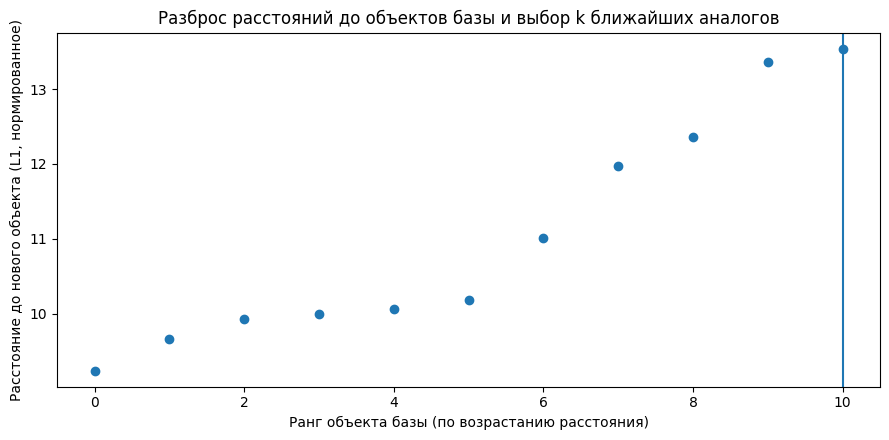

'06-analogs_distance_scatter.png'

In [26]:
# график: расстояние до нового объекта для всей базы, отсортировано
plt.figure(figsize=(9, 4.5))
plt.plot(base_df_sorted["dist"].to_numpy(), marker="o", linestyle="none")
plt.axvline(x=k_eff-1)  # граница k ближайших
plt.xlabel("Ранг объекта базы (по возрастанию расстояния)")
plt.ylabel("Расстояние до нового объекта (L1, нормированное)")
plt.title("Разброс расстояний до объектов базы и выбор k ближайших аналогов")
plt.tight_layout()

plot_path = "06-analogs_distance_scatter.png"
plt.savefig(plot_path, dpi=300)
plt.show()

plot_path


In [27]:
# берём delta по аналогам
delta_typical = {}
delta_scale = {}

for m in metrics:
    deltas = analogs[f"{m}__delta"].astype(float).to_numpy()

    med = np.nanmedian(deltas)
    iqr = np.nanpercentile(deltas, 75) - np.nanpercentile(deltas, 25)
    if not np.isfinite(iqr) or iqr <= 0:
        iqr = EPS

    delta_typical[m] = float(med)
    delta_scale[m] = float(iqr)

delta_typical, delta_scale


({'Culture': 7.199999999999999,
  'Food': 2.4000000000000004,
  'Game': 3.2,
  'POI': 1.5},
 {'Culture': 9.000000000000002, 'Food': 4.875, 'Game': 4.4, 'POI': 1.5})

In [28]:
def importance_level(metric):
    return "important" if metric in IMPORTANT_METRICS_PARK else "secondary"

def recommend_text(metric, status, importance):
    if status == "deficit":
        if importance == "important":
            return f"Дефицит по {metric}: рекомендуется усилить/разместить соответствующие элементы."
        elif importance == "secondary":
            return f"Дефицит по {metric}: желательно предусмотреть при возможности."
        else:
            return f"Дефицит по {metric}: не является приоритетом."
    if status == "normal":
        return f"{metric}: соответствует типичному уровню; дополнительное размещение не требуется."
    if status == "surplus":
        if importance == "important":
            return f"Профицит по {metric}: сильная сторона территории, можно использовать как драйвер."
        return f"Профицит по {metric}: потенциальный ресурс."
    return ""


In [29]:
rows = []
for m in metrics:
    new_v = new_vals[m]
    dt = delta_typical[m]
    ds = delta_scale[m]

    target = new_v + dt
    score = (new_v - target) / ds
    base_before_ref = float(np.nanmedian(analogs[f"{m}__before"].astype(float).to_numpy()))
    target_ref = base_before_ref + dt

    score2 = (new_v - target_ref) / ds

    if new_v < target_ref - ds:
        status = "deficit"
    elif new_v > target_ref + ds:
        status = "surplus"
    else:
        status = "normal"

    imp = importance_level(m)
    text = recommend_text(m, status, imp)

    rows.append({
        "metric": m,
        "new_value": new_v,
        "base_before_ref(median_analogs)": base_before_ref,
        "delta_typical(median_delta_analogs)": dt,
        "delta_scale(IQR_delta_analogs)": ds,
        "target_ref": target_ref,
        "score": score2,
        "status": status,
        "importance": imp,
        "recommendation_text": text
    })

rec_df = pd.DataFrame(rows).sort_values(
    ["importance", "status"],
    ascending=[True, True]
)

out_xlsx = "06-Recommendation_matrix.xlsx"
rec_df.to_excel(out_xlsx, index=False)

out_xlsx, rec_df.head(10)


('06-Recommendation_matrix.xlsx',
     metric  new_value  base_before_ref(median_analogs)  \
 2     Game       2.80                          14.0000   
 3      POI       4.50                           4.3125   
 0  Culture      70.65                          14.4000   
 1     Food      16.40                           5.6000   
 
    delta_typical(median_delta_analogs)  delta_scale(IQR_delta_analogs)  \
 2                                  3.2                           4.400   
 3                                  1.5                           1.500   
 0                                  7.2                           9.000   
 1                                  2.4                           4.875   
 
    target_ref     score   status importance  \
 2     17.2000 -3.272727  deficit  important   
 3      5.8125 -0.875000   normal  important   
 0     21.6000  5.450000  surplus  important   
 1      8.0000  1.723077  surplus  secondary   
 
                                  recommendation_t